# 01 - EDA & Wrapped++

My Spotify listening history, 2019-2026 (~172k streams). This notebook is the tour: it
loads the raw export, sanity-checks it, and builds a deeper, more honest *Wrapped* -
**ranked by minutes actually listened, not play count** - then explores when, where,
and how I listen: a listening calendar, a weekly clock, a travel trail, my discovery
rate, and the artists I briefly obsessed over.

It's the foundation for the two modelling notebooks (02 prediction, 03 taste structure).
Run top-to-bottom; the data is found automatically and nothing leaves the machine.

In [1]:
import sys
from pathlib import Path

# Make the local package importable without `pip install -e .`
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "scripts" / "helper_scripts.py").exists():
        sys.path.insert(0, str(_p / "scripts"))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = ["DejaVu Sans", "Meiryo"]  # CJK fallback for non-Latin artist names
GREEN = "#1DB954"
pd.set_option("display.max_columns", 40)

from helper_scripts import load_streams, clean_streams

df = clean_streams(load_streams())
print(f"{len(df):,} streams loaded:", df["ts"].min().date(), "->", df["ts"].max().date())

172,078 streams loaded: 2019-04-09 -> 2026-04-12


## 1. What's in the data?

One row per stream (a single play). The columns that matter: **when** (`ts`, in UTC),
**how long** (`ms_played`), **where** (`conn_country`), **device** (`platform`), and the
**behaviour** flags (`skipped`, `shuffle`, `reason_start`/`reason_end`). `clean_streams`
has already coerced the booleans, dropped duplicate logs, and added `minutes`, `is_track`
and an `is_real_listen` flag (played ≥ 30s).

In [2]:
print("rows x cols:", df.shape)
df.dtypes

rows x cols: (172078, 31)


ts                         datetime64[us, UTC]
platform                                   str
ms_played                                int64
conn_country                               str
ip_addr                                    str
track                                      str
artist                                     str
album                                      str
spotify_track_uri                          str
episode_name                               str
episode_show_name                          str
spotify_episode_uri                        str
audiobook_title                         object
audiobook_uri                           object
audiobook_chapter_uri                   object
audiobook_chapter_title                 object
reason_start                               str
reason_end                                 str
shuffle                                boolean
skipped                                boolean
offline                                boolean
offline_times

In [3]:
# how complete is each column?
df.isna().mean().sort_values(ascending=False).head(8).to_frame("missing_fraction").round(3)

,missing_fraction
audiobook_title,1.000
audiobook_chapter_uri,1.000
audiobook_uri,1.000
audiobook_chapter_title,1.000
episode_show_name,1.000
spotify_episode_uri,1.000
episode_name,1.000
offline_timestamp,0.592


## 2. The headline numbers

Total time, library size, and how often I bail on a track. I restrict to music rows
(`is_track`) and measure time as minutes summed from `ms_played`.

In [4]:
tracks = df[df["is_track"]]
minutes = tracks["minutes"].sum()
stats = {
    "first stream":     str(df["ts"].min().date()),
    "last stream":      str(df["ts"].max().date()),
    "track streams":    f"{len(tracks):,}",
    "minutes listened": f"{minutes:,.0f}",
    "~ full days":      f"{minutes/60/24:,.1f}",
    "unique artists":   f"{tracks['artist'].nunique():,}",
    "unique tracks":    f"{tracks['spotify_track_uri'].nunique():,}",
    "skip rate":        f"{tracks['skipped'].mean():.1%}",
}
for k, v in stats.items():
    print(f"{k:>16}: {v}")

    first stream: 2019-04-09
     last stream: 2026-04-12
   track streams: 172,010
minutes listened: 248,304
     ~ full days: 172.4
  unique artists: 4,603
   unique tracks: 18,711
       skip rate: 23.7%


~172 days of audio over 7 years, across ~4.6k artists - and roughly one play in four
gets skipped. I come back to that skip rate at the end (and model it in notebook 02).

## 3. Top artists & tracks - by *time*, not plays

Play count quietly rewards short songs on repeat. Ranking by **minutes** is the honest
version of Wrapped, so that's what I use throughout.

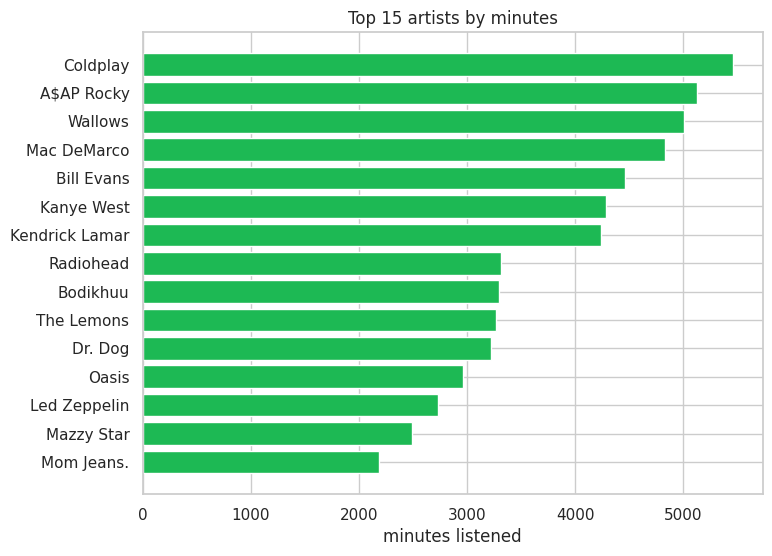

In [5]:
top_art = tracks.groupby("artist")["minutes"].sum().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_art.index[::-1], top_art.values[::-1], color=GREEN)
ax.set_xlabel("minutes listened"); ax.set_title("Top 15 artists by minutes")
plt.show()

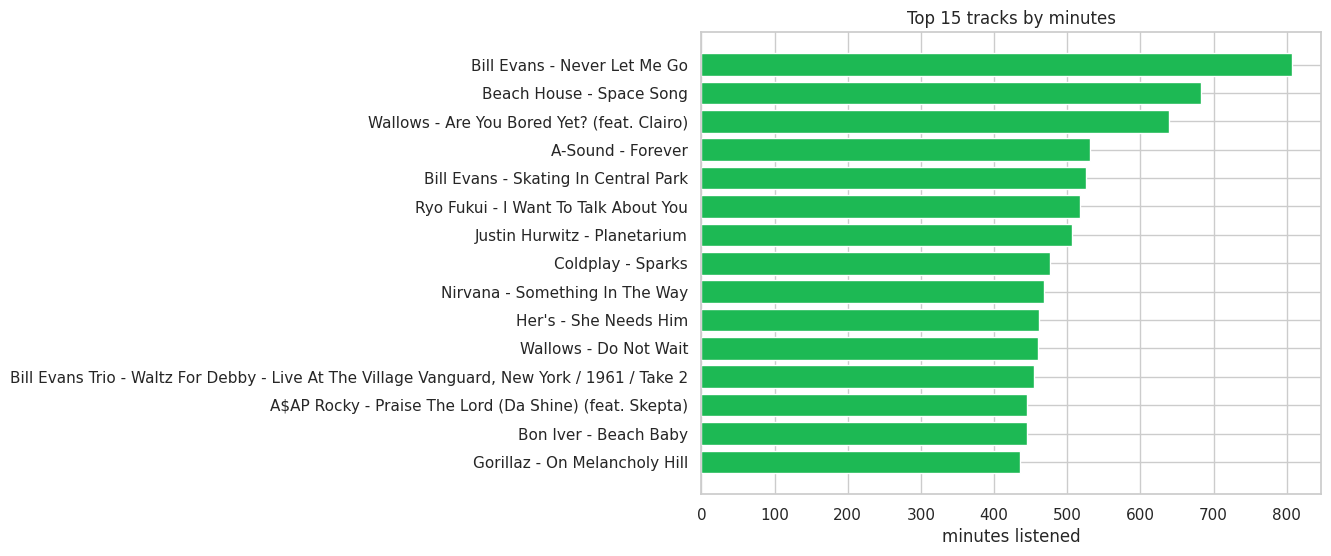

In [6]:
top_trk = (tracks.groupby(["artist", "track"])["minutes"].sum()
           .sort_values(ascending=False).head(15))
labels = [f"{a} - {t}" for a, t in top_trk.index]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(labels[::-1], top_trk.values[::-1], color=GREEN)
ax.set_xlabel("minutes listened"); ax.set_title("Top 15 tracks by minutes")
plt.show()

## 4. Listening over time

How much I listened per year and per month. (2019 and 2026 are partial years - my account
starts in April 2019 and the export ends in April 2026 - so the dips at each end are
expected, not a drop in interest.)

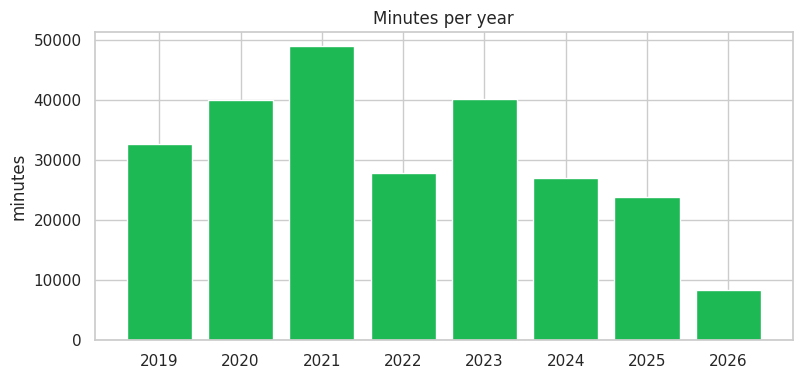

year
2019    32542
2020    39874
2021    48870
2022    27786
2023    40199
2024    27010
2025    23718
2026     8304
Name: minutes, dtype: int64

In [7]:
per_year = tracks.groupby("year")["minutes"].sum()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(per_year.index.astype(str), per_year.values, color=GREEN)
ax.set_ylabel("minutes"); ax.set_title("Minutes per year")
plt.show()
per_year.round().astype(int)

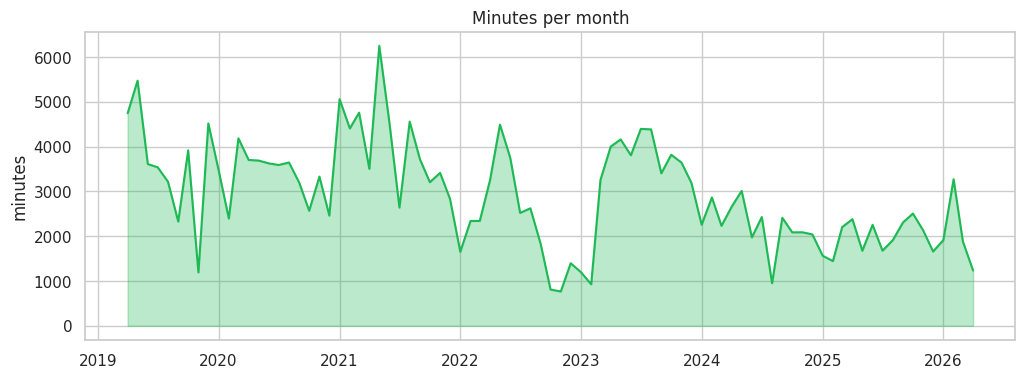

In [8]:
monthly = (tracks.assign(month=tracks["ts"].dt.tz_localize(None).dt.to_period("M"))
           .groupby("month")["minutes"].sum())
x = monthly.index.to_timestamp()
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(x, monthly.values, color=GREEN, alpha=0.3)
ax.plot(x, monthly.values, color=GREEN)
ax.set_ylabel("minutes"); ax.set_title("Minutes per month")
plt.show()

## 5. My listening calendar

Daily minutes laid out GitHub-contributions style - one weekday × week grid per year,
darker = more listening. Great for spotting streaks and quiet stretches at a glance.
Capped at the 99th percentile so a few huge days don't wash everything out.

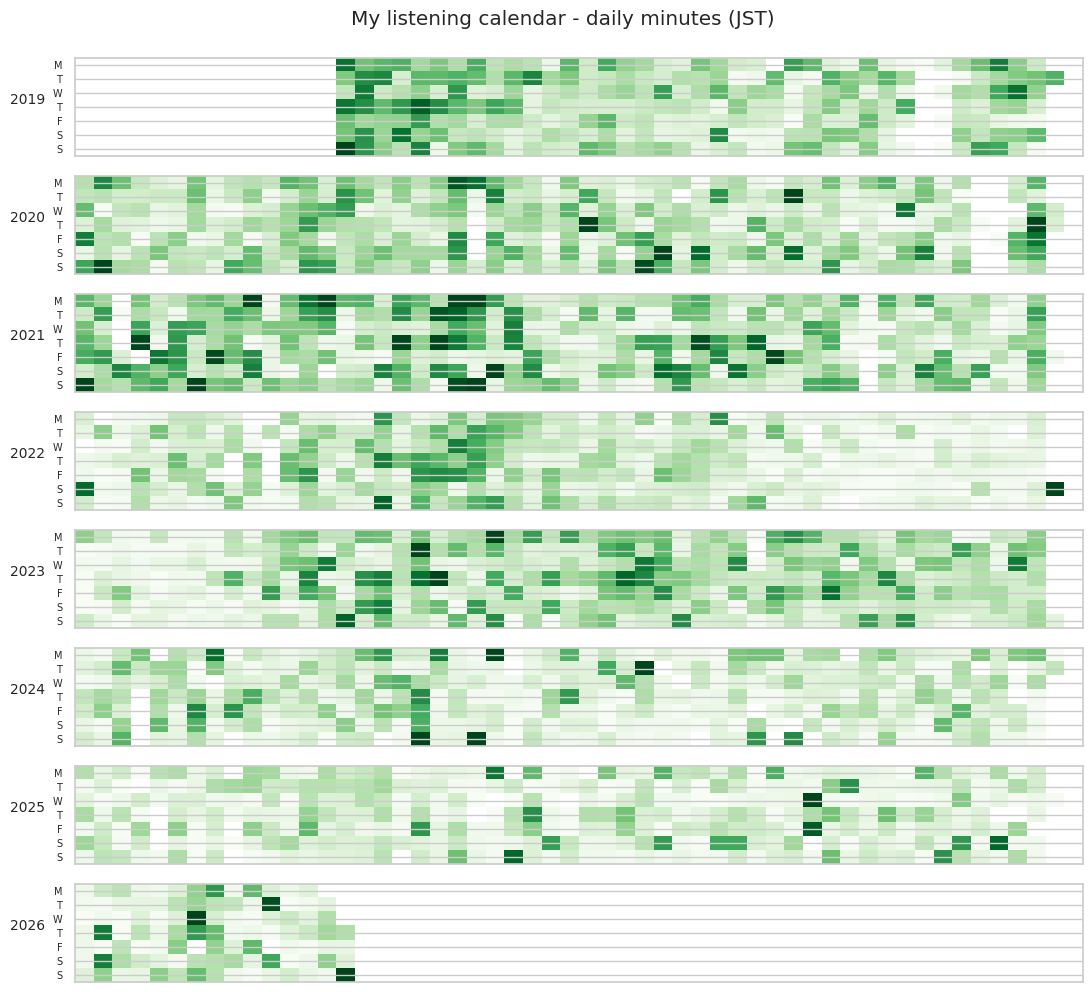

In [9]:
jst = tracks["ts"].dt.tz_convert("Asia/Tokyo")
daily = tracks.assign(date=jst.dt.normalize()).groupby("date")["minutes"].sum()

cal = pd.DataFrame({"minutes": daily.values}, index=pd.DatetimeIndex(daily.index))
cal["year"] = cal.index.year
cal["weekday"] = cal.index.weekday            # 0 = Monday
cal["week"] = (cal.index.dayofyear - 1) // 7  # 0..52 within the year

years = sorted(cal["year"].unique())
vmax = float(np.nanpercentile(cal["minutes"], 99))
fig, axes = plt.subplots(len(years), 1, figsize=(13, 1.5 * len(years)))
for ax, yr in zip(np.atleast_1d(axes), years):
    grid = np.full((7, 54), np.nan)
    sub = cal[cal["year"] == yr]
    grid[sub["weekday"].to_numpy(), sub["week"].to_numpy()] = sub["minutes"].to_numpy()
    ax.imshow(grid, aspect="auto", cmap="Greens", vmin=0, vmax=vmax)
    ax.set_yticks(range(7)); ax.set_yticklabels(list("MTWTFSS"), fontsize=7)
    ax.set_xticks([])
    ax.set_ylabel(yr, rotation=0, labelpad=18, fontsize=10)
fig.suptitle("My listening calendar - daily minutes (JST)", y=0.92)
plt.show()

## 6. My listening clock - in local time

When in the day/week do I listen? Timestamps are stored in **UTC**, but I listen mostly
from Japan, so I convert to **JST** before bucketing by hour - otherwise the peak is
shifted ~9 hours and reads wrong.

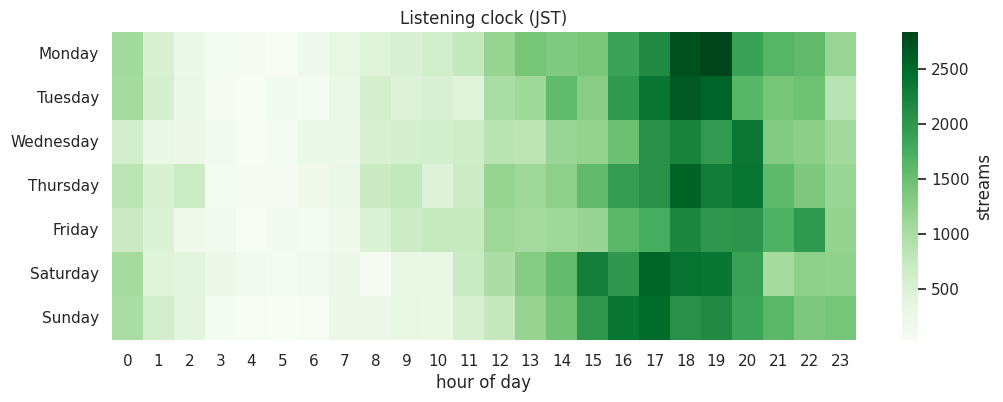

In [10]:
clock = (tracks.assign(hour=jst.dt.hour, weekday=jst.dt.day_name())
         .pivot_table(index="weekday", columns="hour", values="track", aggfunc="size"))
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
clock = clock.reindex(order).fillna(0)
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(clock, cmap="Greens", ax=ax, cbar_kws={"label": "streams"})
ax.set_title("Listening clock (JST)"); ax.set_xlabel("hour of day"); ax.set_ylabel("")
plt.show()

## 7. Where I listened - the travel signal

`conn_country` quietly logs the country of each stream, so my listening doubles as a rough
travel log.

In [11]:
country = (tracks.groupby("conn_country")
           .agg(streams=("track", "size"), minutes=("minutes", "sum"))
           .sort_values("streams", ascending=False))
country["minutes"] = country["minutes"].round().astype(int)
country

,streams,minutes
conn_country,,
JP,170433,246416
MN,1494,1805
ID,74,60
US,4,11
FR,1,5
KR,1,3
GB,1,4
PA,1,0
SG,1,0


In [12]:
# months with non-home (non-JP) listening = roughly when/where I travelled
non_home = tracks[tracks["conn_country"] != "JP"].copy()
non_home["month"] = non_home["ts"].dt.tz_localize(None).dt.to_period("M").astype(str)
(non_home.groupby(["month", "conn_country"]).size().rename("streams")
 .reset_index().sort_values("month"))

,month,conn_country,streams
0,2019-12,US,1
1,2020-02,US,3
2,2020-03,GB,1
3,2021-02,FR,1
4,2021-02,PA,1
5,2022-03,MN,758
6,2023-09,MN,736
7,2024-08,ID,74
8,2024-08,SG,1
9,2025-12,KR,1


## 8. Discovery - am I still exploring?

Counting each artist's *first* appearance per month shows how many genuinely new artists I
picked up over time - a simple proxy for exploration vs. settling into favourites.

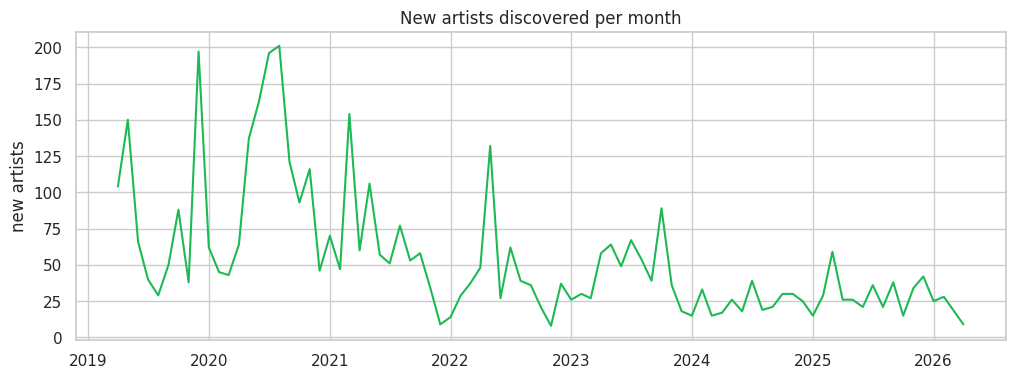

In [13]:
first_seen = tracks.dropna(subset=["artist"]).groupby("artist")["ts"].min().dt.tz_localize(None)
new_per_month = first_seen.dt.to_period("M").value_counts().sort_index()
x = new_per_month.index.to_timestamp()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(x, new_per_month.values, color=GREEN)
ax.set_ylabel("new artists"); ax.set_title("New artists discovered per month")
plt.show()

## 9. My obsessions

The personal bit: for each artist I find their single biggest *week* of listening. The
artists with the most intense peak weeks are the ones I briefly couldn't stop playing.

In [14]:
t2 = tracks.dropna(subset=["artist"]).copy()
t2["week"] = t2["ts"].dt.tz_localize(None).dt.to_period("W")
weekly = t2.groupby(["artist", "week"])["minutes"].sum()

peak = weekly.groupby("artist").max()
peak_when = weekly.groupby("artist").idxmax()
total = t2.groupby("artist")["minutes"].sum()

obs = pd.DataFrame({"peak_week_min": peak, "total_min": total})
obs = obs[obs["total_min"] > 60].sort_values("peak_week_min", ascending=False).head(15)
obs["peak_week"] = [str(peak_when[a][1]) for a in obs.index]
obs.round().astype({"peak_week_min": int, "total_min": int})

,peak_week_min,total_min,peak_week
artist,,,
Bill Evans,626,4460,2020-12-21/2020-12-27
M83,622,1241,2023-05-15/2023-05-21
Bodikhuu,429,3294,2019-05-06/2019-05-12
Coldplay,412,5463,2019-04-15/2019-04-21
Wallows,386,5009,2019-04-08/2019-04-14
Foster The People,354,1897,2020-01-13/2020-01-19
Bill Evans Trio,340,1793,2021-01-25/2021-01-31
$uicideboy$,335,638,2020-08-17/2020-08-23
A$AP Rocky,328,5125,2022-05-30/2022-06-05


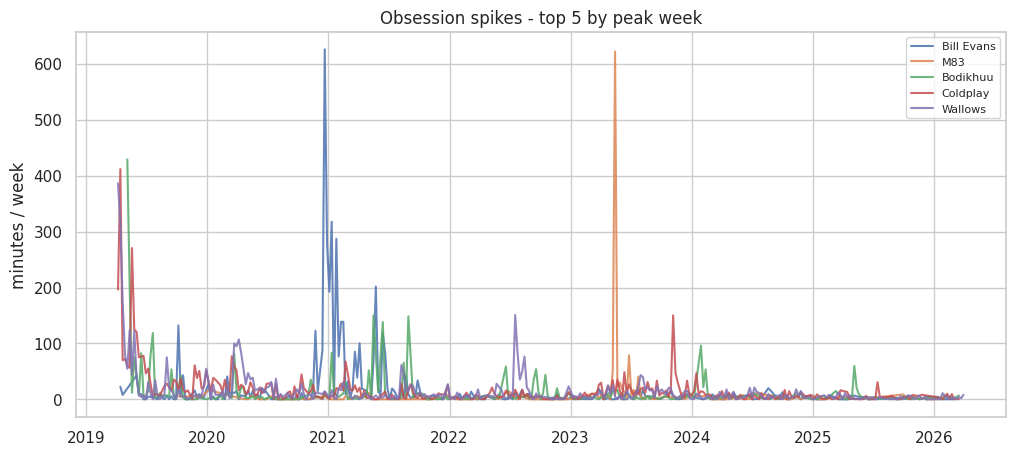

In [15]:
top5 = obs.index[:5]
fig, ax = plt.subplots(figsize=(12, 5))
for a in top5:
    s = weekly.loc[a]
    ax.plot(s.index.to_timestamp(), s.values, label=a, alpha=0.85)
ax.set_ylabel("minutes / week"); ax.set_title("Obsession spikes - top 5 by peak week")
ax.legend(fontsize=8)
plt.show()

## 10. Skip behaviour over time - a teaser for notebook 02

That ~24% overall skip rate didn't hold steady. The trend below is the hook for the skip
model in `02_prediction.ipynb`.

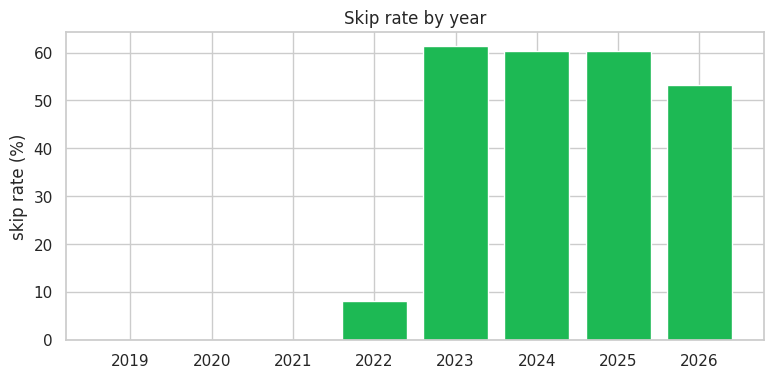

year
2019     0.0
2020     0.0
2021     0.0
2022     8.0
2023    61.3
2024    60.4
2025    60.3
2026    53.2
Name: skipped, dtype: Float64

In [16]:
skip_year = tracks.groupby("year")["skipped"].mean()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(skip_year.index.astype(str), skip_year.values * 100, color=GREEN)
ax.set_ylabel("skip rate (%)"); ax.set_title("Skip rate by year")
plt.show()
(skip_year * 100).round(1)

## Takeaways

- ~172 days of listening; indie / hip-hop / jazz dominate *by time*.
- Clear morning and weekend-afternoon peaks (in JST); listening comes in streaks.
- The data remembers my travels (JP home base, plus trips showing up as other countries).
- Skip rate climbs sharply in later years - picked apart in **`02_prediction.ipynb`** -
  and the structure of my taste (modes + artist embeddings) is in **`03_taste_structure.ipynb`**.

The calendar is the one I keep coming back to. If I squint I can pick out exam weeks, a
couple of trips, and the stretches where I basically lived inside one album. And the
headline answer to my original question: my own numbers line up with what Wrapped showed me
over the years, which was honestly a bit of a relief.